<a href="https://colab.research.google.com/github/billurbektas/TP_JSDM/blob/main/Calanda_JSDM/R/02_model/05_sjsdm_experiments_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# sjSDM Model Experiments Pipeline

**Experiments:**
1. Full grid search (spatial_form x alpha x lambda)
2. Decoupled lambda sensitivity
3. Drop-one environmental variable
4. k-fold CV (species AUC, train-test gap, site log-loss)
5. ANOVA sampling saturation

Each run extracts: overall R², full model E/S/C, species-level R²/E/S/C, site-level R²/E/S/C

## Setup: Install packages & mount Drive

The Google drive mounting needs to be conducted when the runtime is configured for Python 3.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


From here on, the runtime needs to be changed to R.

In [1]:
install.packages("sjSDM")
install.packages("tidyverse")
install.packages("conflicted")
install.packages("pROC")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘foreach’, ‘iterators’, ‘RcppTOML’, ‘here’, ‘png’, ‘plyr’, ‘doParallel’, ‘gridExtra’, ‘reticulate’, ‘mvtnorm’, ‘abind’, ‘Metrics’, ‘checkmate’, ‘mathjaxr’, ‘beeswarm’, ‘qgam’, ‘viridis’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(sjSDM)
install_sjSDM(version = "gpu")


── Attaching sjSDM ──────────────────────────────────────────────────── 1.0.7 ──

✖ torch 
✖ torch_optimizer 
✖ pyro 
✖ madgrad 


Torch or other dependencies not found:

	1. Use install_sjSDM() to install Pytorch and conda automatically 
	2. Installation trouble shooting guide: ?installation_help 
	3. If 1) and 2) did not help, please create an issue on <https://github.com/TheoreticalEcology/s-jSDM/issues> (see ?install_diagnostic) 

* Installing Miniconda -- please wait a moment ...

* Downloading 'https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh' ...

+ /usr/bin/bash /tmp/Rtmp1FZK95/Miniforge3-Linux-x86_64.sh -b -u -p '/root/.local/share/r-miniconda'

+ /root/.local/share/r-miniconda/bin/conda update --yes --name base conda

+ /root/.local/share/r-miniconda/bin/conda create --yes --name r-reticulate 'python=3.12' numpy --quiet -c conda-forge

* Miniconda has been successfully installed at "~/.local/share/r-miniconda".

+ /root/.local/share

In [3]:
# Verify GPU
system("nvidia-smi", intern = TRUE)
system("/root/.local/share/r-miniconda/bin/conda run -n r-sjsdm pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --force-reinstall")

[1] "Mon Mar  9 08:27:50 2026       "                                                            
 [2] "+-----------------------------------------------------------------------------------------+"
 [3] "| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |"
 [4] "+-----------------------------------------+------------------------+----------------------+"
 [5] "| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |"
 [6] "| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |"
 [7] "|                                         |                        |               MIG M. |"
 [8] "|=========================================+========================+======================|"
 [9] "|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |"
[10] "| N/A   32C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |"
[11] "|                                         |                        |             Disabled |"
[12] "+-----------------------------------------+------------------------+----------------------+"
[13] ""                                                                                           
[14] "+-----------------------------------------------------------------------------------------+"
[15] "| Processes:                                                                              |"
[16] "|  GPU   GI   CI              PID   Type   Process name                        GPU Memory |"
[17] "|        ID   ID                                                               Usage      |"
[18] "|=========================================================================================|"
[19] "|  No running processes found                                                             |"
[20] "+-----------------------------------------------------------------------------------------+"

Here, the runtime needs to be restarted. On the above menu: **Run all --> Restart session**

In [1]:
library(reticulate)
use_condaenv("r-sjsdm", required = TRUE)

torch <- import("torch")
cat("PyTorch version:", torch$`__version__`, "\n")
cat("CUDA available:", torch$cuda$is_available(), "\n")
cat("CUDA version:", torch$version$cuda, "\n")

PyTorch version: 2.5.1+cu121 
CUDA available: TRUE 
CUDA version: 12.1 


## Load libraries & data

In [2]:
library(sjSDM)
library(tidyverse)
library(conflicted)
library(pROC)

conflict_prefer("select", "dplyr")
conflict_prefer("filter", "dplyr")
conflict_prefer("intersect", "base")

set.seed(42)
seed = 42
session_info = sessionInfo()

── Attaching sjSDM ──────────────────────────────────────────────────── 1.0.7 ──

✔ torch <environment> 
✔ torch_optimizer  
✔ pyro  
✔ madgrad  


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Type 'citation("pROC")' for a citation.

[conflicted] Will prefer dplyr::select over any other package.
[conflicted] Will prefer dplyr::filter over any other package.
[conflicted] Will prefer base::intersect over any other package.


In [3]:
 # ── Fix trailing space bug in sjSDM:::get_null_ll ──
  # Line 346 of anova.R has: inherits(object, "spatial ") — trailing space
  # means spatial models never get spatial_formula = ~0 in the null model.
  # This patch is a 1-character fix applied at runtime.

  local({
    # Get the original function and its environment (sjSDM namespace)
    original = sjSDM:::get_null_ll
    ns_env   = environment(original)

    # Build patched version — identical except "spatial " → "spatial"
    patched = function(object, verbose = TRUE, ...) {
      object_tmp = object
      object_tmp$settings$se = FALSE

      if (inherits(object, "spatial")) {
        null_model = update(object_tmp, env_formula = ~1, spatial_formula = ~0,
                            biotic = bioticStruct(diag = TRUE), verbose = verbose)
        null_pred  = predict(null_model)
      } else {
        null_model = update(object_tmp, env_formula = ~1,
                            biotic = bioticStruct(diag = TRUE), verbose = verbose)
        null_pred  = predict(null_model)
      }

      if (object$family$family$family == "binomial") {
        null_m = stats::dbinom(object$data$Y, 1, null_pred, log = TRUE)
      } else if (object$family$family$family == "poisson") {
        null_m = stats::dpois(object$data$Y, null_pred, log = TRUE)
      } else if (object$family$family$family == "nbinom") {
        check_module()
        torch = pkg.env$torch
        theta = object$theta
        theta = 1.0 / (softplus(theta) + 0.0001)
        theta = matrix(theta, nrow = nrow(null_pred), ncol = ncol(null_pred), byrow = TRUE)
        probs = (1.0 - theta / (theta + null_pred)) + 0.0001
        probs = ifelse(probs < 0.0, 0.0, probs)
        probs = ifelse(probs > 1.0, 1.0 - 0.0001, probs)
        theta = torch$tensor(theta, dtype = torch$float32)
        probs = torch$tensor(probs, dtype = torch$float32)
        YT    = torch$tensor(object$data$Y, dtype = torch$float32)
        null_m = force_r(torch$distributions$NegativeBinomial(
          total_count = theta, probs = probs)$log_prob(YT)$cpu()$data$numpy())
      } else if (object$family$family$family == "gaussian") {
        null_m = sapply(1:ncol(object$data$Y), function(i)
          stats::dnorm(object$data$Y[,i], null_pred[,i],
                       sd = exp(null_model$theta)[i], log = TRUE))
      }
      return(null_m)
    }

    # Set environment to sjSDM namespace so it can see pkg.env, check_module, etc.
    environment(patched) = ns_env

    # Replace in namespace
    assignInNamespace("get_null_ll", patched, ns = "sjSDM")
  })


In [13]:
# ============================================================================
# USER SETTINGS
# ============================================================================

# Google Drive paths
drive_base = "/content/drive/MyDrive/A_ETH/Calanda_JSDM"
data_file = file.path(drive_base, "data_calanda_jsdm_2026-03-06.rds")
results_dir = file.path(drive_base, "results")

# Model settings
device = "gpu"
iterations = 700L
learning_rate = 0.01
sampling_fit = 1000L
anova_samples_fast = 1000L

# Environmental formula
env_formula = as.formula("~summer_temp + fdd + et.annual + slope + rocks_cover +
  trees_cover + shrubs_cover + soil_depth_var +
  tpi + flowdir + nutrient + disturbance")
print(env_formula)

# Toggle experiments
run_exp1 = TRUE   # grid search, to determine alpha and global lambda values
run_exp2 = TRUE   # decoupled lambdas, to determine specific lambda values
run_exp3 = TRUE   # drop-one predictor
run_exp4 = TRUE   # k-fold CV
run_exp5 = FALSE  # ANOVA and model saturation, FALSE because changing them both is too costly
run_exp6 = TRUE   # ANOVA saturation, to see species-level stability of variance partioning
run_exp7 = TRUE   # FIT saturation, showed that increasing model fit sampling does not improve
run_exp8 = FALSE  # Repeated anova sampling, not possible with the current package configuration

# Representative config for Exp 3-5
rep_spatial = "LIN_XY_XY" # updated after the Exp 1-2, space do not gain much with DNN but it might compete for the environment with more complex model.
rep_alpha = 1 # updated after the Exp 1-2, space is too much penalized with alpha = 0
rep_lambda = 0.01 # updated after the Exp 1-2, stable zone for full model R2s.
rep_lambda_env = 0.001 # updated after the Exp 2 # To assure that environment effects remain strong, if not biotic captures it.

~summer_temp + fdd + et.annual + slope + rocks_cover + trees_cover + 
    shrubs_cover + soil_depth_var + tpi + flowdir + nutrient + 
    disturbance


In [15]:
# Load data
cat("Loading data from:", data_file, "\n")
data_calanda_jsdm = readRDS(data_file)
X = data_calanda_jsdm$X
Y = data_calanda_jsdm$Y

cat("X:", nrow(X), "sites x", ncol(X), "predictors\n")
cat("Y:", nrow(Y), "sites x", ncol(Y), "species\n")
cat("X columns:", paste(colnames(X), collapse = ", "), "\n")

altitude = X[, "altitude"]
XY = X[, c("Latitude", "Longitude")]
richness = rowSums(Y)
env_cols = all.vars(env_formula)
Xenv = X[, env_cols, drop = FALSE]

# Create results directories on Drive
for (d in c("results", "results/runs", "results/decoupled",
            "results/dropone", "results/cv", "results/fit_saturation",
            "results/anova_saturation", "results/anova_repeatability")) {
  dir.create(file.path(drive_base, d), showWarnings = FALSE, recursive = TRUE)
}

Loading data from: /content/drive/MyDrive/A_ETH/Calanda_JSDM/data_calanda_jsdm_2026-03-06.rds 
X: 529 sites x 18 predictors
Y: 529 sites x 168 species
X columns: Longitude, Latitude, altitude, slope, summer_temp, fdd, et.annual, soil_depth_mean, soil_depth_var, trees_cover, shrubs_cover, rocks_cover, flowdir, tpi, roughness, snow_sum, nutrient, disturbance 


## Core functions

In [6]:
fit_sjsdm = function(Y_train, Xenv_train, XY_train,
                       env_form = env_formula,
                       spatial_form = "LIN_XY_XY",
                       lambda_env = 0.001, alpha_env = 1,
                       lambda_sp = 0.01, alpha_sp = 1,
                       lambda_bio = 0.01, alpha_bio = 1) {

    env_component = do.call(linear, list(
      data = Xenv_train,
      formula = env_form,
      lambda = lambda_env,
      alpha = alpha_env
    ))

    if (spatial_form == "DNN") {
      sp_component = DNN(
        XY_train,
        formula = ~0 + .,
        hidden = c(30L, 30L),
        activation = "relu",
        bias = FALSE,
        lambda = lambda_sp, alpha = alpha_sp
      )
    } else if (spatial_form == "LIN_XY_XY") {
      sp_component = do.call(linear, list(
        data = XY_train,
        formula = ~0 + Latitude + Longitude + I(Latitude * Longitude),
        lambda = lambda_sp,
        alpha = alpha_sp
      ))
    } else {
      stop("Unknown spatial_form: ", spatial_form)
    }

    sjSDM(
      Y = Y_train,
      env = env_component,
      spatial = sp_component,
      biotic = bioticStruct(lambda = lambda_bio, alpha = alpha_bio,
                            df = ncol(Y_train), reg_on_Cov = FALSE),
      iter = iterations,
      device = device,
      learning_rate = learning_rate,
      sampling = sampling_fit,
      control = sjSDMControl(
        RMSprop(weight_decay = 0.0),
        scheduler = 5L,
        early_stopping_training = 25L,
        lr_reduce_factor = 0.9
      ),
      se = FALSE
    )
  }

In [7]:
extract_partition = function(model, anova_samples = anova_samples_fast) {

    R2 = Rsquared(model, verbose = FALSE)
    an = anova(model, verbose = FALSE, samples = anova_samples)
    res = internalStructure(an, fractions = "proportional",
                            Rsquared = "McFadden", plot = FALSE, negatives = "floor")

    # --- Species-level (r2 already in output) ---
    sp = res$internals$Species

    # --- Site-level ---
    si = res$internals$Sites

    # --- Summary ---
    summary_row = tibble(
      # Model-level
      overall_R2 = R2,
      # Species
      species_R2_mean = mean(sp$r2, na.rm = TRUE),
      species_E_mean = mean(sp$env, na.rm = TRUE),
      species_S_mean = mean(sp$spa, na.rm = TRUE),
      species_C_mean = mean(sp$codist, na.rm = TRUE),
      species_R2_median = median(sp$r2, na.rm = TRUE),
      species_E_median = median(sp$env, na.rm = TRUE),
      species_S_median = median(sp$spa, na.rm = TRUE),
      species_C_median = median(sp$codist, na.rm = TRUE),
      # Sites
      site_R2_mean = mean(si$r2, na.rm = TRUE),
      site_E_mean = mean(si$env, na.rm = TRUE),
      site_S_mean = mean(si$spa, na.rm = TRUE),
      site_C_mean = mean(si$codist, na.rm = TRUE),
      site_R2_median = median(si$r2, na.rm = TRUE),
      site_E_median = median(si$env, na.rm = TRUE),
      site_S_median = median(si$spa, na.rm = TRUE),
      site_C_median = median(si$codist, na.rm = TRUE)
    )

    list(
      R2 = R2,
      anova = an,
      internal_structure = res,
      species = sp,
      sites = si,
      summary = summary_row
    )
  }


In [8]:
build_stratified_folds = function(k = 10, alt, tree_cover, shrub_cover,
                                    disturbance, nutrient, richness,
                                    site_names = NULL,
                                    woody_thresh = 0, # because the values are z-score standardized this means that we are taking above average values.
                                    seednum = seed,
                                    plot = TRUE) {
    n = length(alt)

    set.seed(seednum)

    elev_bin = as.integer(cut(alt,
      breaks = quantile(alt, probs = seq(0, 1, length.out = 6)),
      include.lowest = TRUE))

    woody_class = ifelse((tree_cover + shrub_cover) > woody_thresh, 1L, 0L)

    landuse_score = scale(disturbance)[, 1] + scale(nutrient)[, 1]
    landuse_bin = as.integer(cut(landuse_score,
      breaks = quantile(landuse_score, probs = seq(0, 1, length.out = 4), na.rm = TRUE),
      include.lowest = TRUE))
    landuse_bin[is.na(landuse_bin)] = 1L

    richness_bin = as.integer(cut(richness,
      breaks = quantile(richness, probs = seq(0, 1, length.out = 4)),
      include.lowest = TRUE))

    strata = paste(elev_bin, woody_class, landuse_bin, richness_bin, sep = "_")
    strata_factor = as.factor(strata)
    fold_ids = rep(NA_integer_, n) #- Creates an empty vector of fold IDs for all n sites
    if (!is.null(site_names)) names(fold_ids) = site_names


  # - For each stratum:
  #  - idx = which sites belong to this stratum (e.g. 7 sites)
  #  - perm = sample(seq_len(k)) = random permutation of 1-10, e.g. [6, 3, 9, 1, 7, 4, 10, 2, 8, 5]
  #  - rep(perm, length.out = 7) = [6, 3, 9, 1, 7, 4, 10] — assigns the 7 sites to folds in that random order, recycling if the stratum had more than 10 sites

    for (s in levels(strata_factor)) {
      idx = which(strata_factor == s)
      perm = sample(seq_len(k))
      fold_ids[idx] = rep(perm, length.out = length(idx))
    }

    if (plot) {
      cat("\n--- Counts per elevation bin per fold ---\n")
      print(table(fold = fold_ids, elev_bin = elev_bin))

      cat("\n--- Counts per land-use bin per fold ---\n")
      print(table(fold = fold_ids, landuse_bin = landuse_bin))

      cat("\n--- Counts per richness bin per fold ---\n")
      print(table(fold = fold_ids, richness_bin = richness_bin))

      cat("\n--- Counts per woody class per fold ---\n")
      print(table(fold = fold_ids, woody_class = woody_class))

      cat("\n--- Min/max altitude and woody fraction per fold ---\n")
      fold_diag = tibble(fold = fold_ids, altitude = alt, woody = woody_class) %>%
        group_by(fold) %>%
        summarise(
          n = n(),
          alt_min = min(altitude),
          alt_max = max(altitude),
          woody_frac = mean(woody),
          .groups = "drop"
        )
      print(as.data.frame(fold_diag))

      # --- PCA plot ---
      df_strata = tibble(
        altitude = scale(alt)[, 1],
        woody_cover = scale(tree_cover + shrub_cover)[, 1],
        landuse_score = scale(landuse_score)[, 1],
        richness = scale(richness)[, 1],
        fold = factor(fold_ids),
        stratum = strata_factor
      )

      pca_strata = prcomp(df_strata %>% select(altitude, woody_cover, landuse_score, richness))
      df_pca = tibble(
        PC1 = pca_strata$x[, 1],
        PC2 = pca_strata$x[, 2],
        fold = df_strata$fold
      )

      var_exp = round(100 * summary(pca_strata)$importance[2, 1:2], 1)

      loadings = as.data.frame(pca_strata$rotation[, 1:2])
      loadings$variable = rownames(loadings)
      arrow_scale = max(abs(df_pca$PC1), abs(df_pca$PC2)) * 0.8

      p = ggplot(df_pca, aes(x = PC1, y = PC2, color = fold)) +
        geom_point(alpha = 0.6, size = 2) +
        geom_segment(data = loadings,
                     aes(x = 0, y = 0, xend = PC1 * arrow_scale, yend = PC2 * arrow_scale),
                     inherit.aes = FALSE,
                     arrow = arrow(length = unit(0.2, "cm")),
                     color = "grey30", linewidth = 0.6) +
        geom_text(data = loadings,
                  aes(x = PC1 * arrow_scale * 1.12, y = PC2 * arrow_scale * 1.12, label = variable),
                  inherit.aes = FALSE, size = 3.2, color = "grey20") +
        labs(title = "Stratified folds in strata-variable PCA space",
             x = paste0("PC1 (", var_exp[1], "%)"),
             y = paste0("PC2 (", var_exp[2], "%)"),
             color = "Fold") +
        theme_bw() +
        theme(legend.position = "right")

      print(p)
    }

    folds = lapply(seq_len(k), function(i) {
      idx = which(fold_ids == i)
      if (!is.null(site_names)) names(idx) = site_names[idx]
      idx
    })
    folds
  }


Config: LIN_XY_XY alpha= 1 lambda= 0.01 

--- Counts per elevation bin per fold ---
    elev_bin
fold  1  2  3  4  5
  1  11 13 10 10  9
  2  11  8 11 13 11
  3  11 11  9 11 11
  4  12 10 12 11 10
  5  10 11 10  8 12
  6  12 12 10 10 12
  7   9 12 12 11 11
  8  10 10  9  9  9
  9   8 11 11 11 10
  10 12  8 11 12 11

--- Counts per land-use bin per fold ---
    landuse_bin
fold  1  2  3
  1  16 18 19
  2  17 19 18
  3  17 19 17
  4  17 19 19
  5  18 18 15
  6  19 20 17
  7  20 17 18
  8  16 15 16
  9  18 14 19
  10 19 17 18

--- Counts per richness bin per fold ---
    richness_bin
fold  1  2  3
  1  18 16 19
  2  19 17 18
  3  19 19 15
  4  17 17 21
  5  16 20 15
  6  20 16 20
  7  16 20 19
  8  15 17 15
  9  20 16 15
  10 20 16 18

--- Counts per woody class per fold ---
    woody_class
fold  0  1
  1  36 17
  2  37 17
  3  38 15
  4  40 15
  5  36 15
  6  38 18
  7  38 17
  8  34 13
  9  36 15
  10 38 16

--- Min/max altitude and woody fraction per fold ---
   fold  n   alt_min  alt_

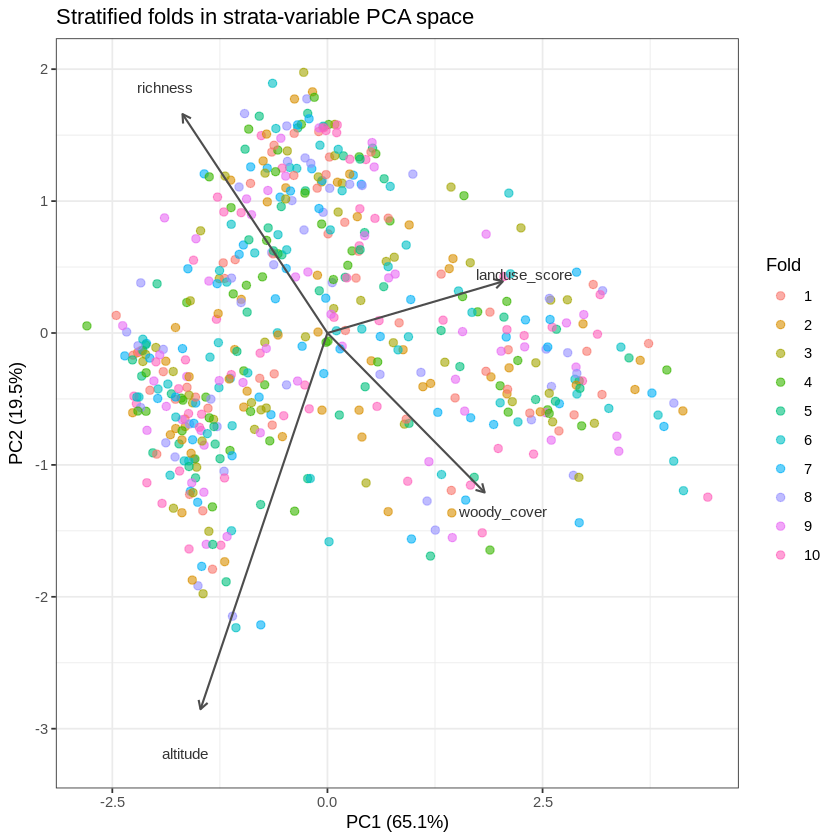

In [ ]:
# Check the balance of the design
k = 10
    cat("Config:", rep_spatial, "alpha=", rep_alpha, "lambda=", rep_lambda, "\n")

    folds = build_stratified_folds(
      k = k, alt = altitude,
      tree_cover = Xenv[, "trees_cover"],
      shrub_cover = Xenv[, "shrubs_cover"],
      disturbance = Xenv[, "disturbance"],
      nutrient = Xenv[, "nutrient"],
      richness = richness,
      site_names = rownames(Y)
    )
    str(folds)
    cat("Fold sizes:", paste(sapply(folds, length), collapse = ", "), "\n\n")

## Experiment 1: Full grid search

In [ ]:
if (run_exp1) {
  cat("\n", strrep("=", 60), "\n")
    cat("EXPERIMENT 1: Full grid search\n")
    cat(strrep("=", 60), "\n")

    grid = expand.grid(
      spatial_form = c("DNN", "LIN_XY_XY"),
      alpha_common = c(0, 0.5, 1),
      lambda_common = c(0.001, 0.01, 0.1, 0.5, 1),
      stringsAsFactors = FALSE
    ) %>%
      mutate(run_id = paste0(spatial_form, "_a", alpha_common, "_l", lambda_common))

    cat("Total runs:", nrow(grid), "\n\n")

    print(grid) # check the grid design
  }


EXPERIMENT 1: Full grid search
Total runs: 30 

   spatial_form alpha_common lambda_common                run_id
1           DNN          0.0         0.001         DNN_a0_l0.001
2     LIN_XY_XY          0.0         0.001   LIN_XY_XY_a0_l0.001
3           DNN          0.5         0.001       DNN_a0.5_l0.001
4     LIN_XY_XY          0.5         0.001 LIN_XY_XY_a0.5_l0.001
5           DNN          1.0         0.001         DNN_a1_l0.001
6     LIN_XY_XY          1.0         0.001   LIN_XY_XY_a1_l0.001
7           DNN          0.0         0.010          DNN_a0_l0.01
8     LIN_XY_XY          0.0         0.010    LIN_XY_XY_a0_l0.01
9           DNN          0.5         0.010        DNN_a0.5_l0.01
10    LIN_XY_XY          0.5         0.010  LIN_XY_XY_a0.5_l0.01
11          DNN          1.0         0.010          DNN_a1_l0.01
12    LIN_XY_XY          1.0         0.010    LIN_XY_XY_a1_l0.01
13          DNN          0.0         0.100           DNN_a0_l0.1
14    LIN_XY_XY          0.0         0.10

In [ ]:
if (run_exp1) {
  exp1_summaries = list()

    for (i in seq_len(nrow(grid))) {

      cfg = grid[i, ]
      run_file = file.path(drive_base, "results", "runs", paste0(cfg$run_id, ".rds"))

      if (file.exists(run_file)) {
        cat("[", i, "/", nrow(grid), "] Cached:", cfg$run_id, "\n")
        flush.console()
        run_data = readRDS(run_file)
      } else {
        cat("[", i, "/", nrow(grid), "] Fitting:", cfg$run_id, "\n")
        flush.console()

        t0 = Sys.time()
        model = fit_sjsdm(
          Y_train = Y, Xenv_train = Xenv, XY_train = XY,
          spatial_form = cfg$spatial_form,
          env_form = env_formula,
          lambda_env = cfg$lambda_common, alpha_env = cfg$alpha_common,
          lambda_sp = cfg$lambda_common, alpha_sp = cfg$alpha_common,
          lambda_bio = cfg$lambda_common, alpha_bio = cfg$alpha_common
        )
        t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
        cat("  Fit done in", t_fit, "min\n")
        flush.console()

        cat("[", i, "/", nrow(grid), "] Variance partitioning:", cfg$run_id, "\n")
        flush.console()
        t0 = Sys.time()
        partition = extract_partition(model)
        t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
        cat("  VP done in", t_vp, "min\n")
        flush.console()

        run_data = list(config = cfg, model = model, partition = partition)
        saveRDS(run_data, run_file)
        cat("  -> Saved (total:", as.numeric(t_fit) + as.numeric(t_vp), "min)\n")
        flush.console()
      }

      exp1_summaries[[i]] = bind_cols(cfg, run_data$partition$summary)
    }

    summary_exp1 = bind_rows(exp1_summaries)
    write_csv(summary_exp1, file.path(drive_base, "results", "summary_exp1_grid.csv"))
    cat("\nSaved summary_exp1_grid.csv\n")
    flush.console()
    print(summary_exp1)
  }

## Experiment 2: Decoupled lambda sensitivity

In [ ]:
cat("\n", strrep("=", 60), "\n")
    cat("EXPERIMENT 2: Decoupled lambda sensitivity\n")
    cat(strrep("=", 60), "\n")

    lambda_anchor = 0.01
    lambda_values = c(0.001, 0.01, 0.1)
    alpha_values  = c(0, 0.5, 1)

    grid_decoupled = expand.grid(
      spatial_form = "LIN_XY_XY",
      vary         = c("lambda_env", "lambda_sp", "lambda_bio"),
      lambda_vary  = lambda_values,
      alpha_common = alpha_values,
      stringsAsFactors = FALSE
    ) %>%
      mutate(
        lambda_env = ifelse(vary == "lambda_env", lambda_vary, lambda_anchor),
        lambda_sp  = ifelse(vary == "lambda_sp",  lambda_vary, lambda_anchor),
        lambda_bio = ifelse(vary == "lambda_bio", lambda_vary, lambda_anchor),
        run_id = paste0("decoupled_", spatial_form, "_", vary, "_", lambda_vary, "_a", alpha_common)
      ) %>%
      filter(lambda_vary != lambda_anchor)

    cat("Total runs:", nrow(grid_decoupled), "\n\n")
    print(grid_decoupled)

In [ ]:
if (run_exp2) {

    exp2_summaries = list()

    for (i in seq_len(nrow(grid_decoupled))) {

      cfg = grid_decoupled[i, ]
      run_file = file.path(drive_base, "results", "decoupled", paste0(cfg$run_id, ".rds"))

      if (file.exists(run_file)) {
        cat("[", i, "/", nrow(grid_decoupled), "] Cached:", cfg$run_id, "\n")
        flush.console()
        run_data = readRDS(run_file)
      } else {
        cat("[", i, "/", nrow(grid_decoupled), "] Fitting:", cfg$run_id, "\n")
        flush.console()

        model = fit_sjsdm(
          Y_train = Y, Xenv_train = Xenv, XY_train = XY,
          spatial_form = cfg$spatial_form,
          lambda_env = cfg$lambda_env, alpha_env = cfg$alpha_common,
          lambda_sp  = cfg$lambda_sp,  alpha_sp  = cfg$alpha_common,
          lambda_bio = cfg$lambda_bio, alpha_bio = cfg$alpha_common
        )

        partition = extract_partition(model)

        run_data = list(config = cfg, model = model, partition = partition)
        saveRDS(run_data, run_file)
        cat("  -> Saved\n")
        flush.console()
      }

      exp2_summaries[[i]] = bind_cols(
        cfg %>% select(run_id, spatial_form, vary, lambda_vary, alpha_common,
                       lambda_env, lambda_sp, lambda_bio),
        run_data$partition$summary
      )
    }

    summary_exp2 = bind_rows(exp2_summaries)
    write_csv(summary_exp2, file.path(drive_base, "results", "summary_exp2_decoupled.csv"))
    cat("\nSaved summary_exp2_decoupled.csv\n")
    flush.console()
    print(summary_exp2)
  }

[ 1 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_env_0.001_a0 
[1] 0.493031
  -> Saved
[ 2 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_sp_0.001_a0 
[1] 0.4721591
  -> Saved
[ 3 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_bio_0.001_a0 
[1] 0.466593
  -> Saved
[ 4 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_env_0.1_a0 
[1] 0.3927647
  -> Saved
[ 5 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_sp_0.1_a0 
[1] 0.4514076
  -> Saved
[ 6 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_bio_0.1_a0 
[1] 0.4097039
  -> Saved
[ 7 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_env_0.001_a0.5 
[1] 0.4980999
  -> Saved
[ 8 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_sp_0.001_a0.5 
[1] 0.4809219
  -> Saved
[ 9 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_bio_0.001_a0.5 
[1] 0.4694481
  -> Saved
[ 10 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_env_0.1_a0.5 
[1] 0.3962439
  -> Saved
[ 11 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_sp_0.1_a0.5 
[1] 0.4616691
  -> Saved
[ 12 / 18 ] Fitting: decoupled_LIN_XY_XY_lambda_bio_0.1_a0


## Experiment 2b: Reproducibility check for two identical runs with same configuration



In [ ]:
 cat("\n", strrep("=", 60), "\n")
  cat("REPRODUCIBILITY CHECK: Two identical LIN_XY_XY a=1 l=0.01 fits\n")
  cat(strrep("=", 60), "\n")

  repro_config = list(spatial_form = "LIN_XY_XY", alpha = 1, lambda = 0.01)

  for (run_i in 1:2) {
    run_file = file.path(drive_base, "results", paste0("repro_check_run", run_i, ".rds"))

    if (file.exists(run_file)) {
      cat("[Run", run_i, "] Cached\n")
      flush.console()
    } else {
      cat("[Run", run_i, "] Fitting...\n")
      flush.console()

      t0 = Sys.time()
      model = fit_sjsdm(
        Y_train = Y, Xenv_train = Xenv, XY_train = XY,
        spatial_form = repro_config$spatial_form,
        env_form = env_formula,
        lambda_env = repro_config$lambda, alpha_env = repro_config$alpha,
        lambda_sp  = repro_config$lambda, alpha_sp  = repro_config$alpha,
        lambda_bio = repro_config$lambda, alpha_bio = repro_config$alpha
      )
      t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
      cat("  Fit done in", t_fit, "min\n")
      flush.console()

      cat("[Run", run_i, "] Variance partitioning...\n")
      flush.console()
      t0 = Sys.time()
      partition = extract_partition(model)
      t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
      cat("  VP done in", t_vp, "min\n")
      flush.console()

      run_data = list(config = repro_config, model = model, partition = partition)
      saveRDS(run_data, run_file)
      cat("  -> Saved (total:", as.numeric(t_fit) + as.numeric(t_vp), "min)\n")
      flush.console()
    }
  }

  # --- Compare the two runs ---
  cat("\n", strrep("-", 60), "\n")
  cat("COMPARISON\n")
  cat(strrep("-", 60), "\n")

  r1 = readRDS(file.path(drive_base, "results", "repro_check_run1.rds"))
  r2 = readRDS(file.path(drive_base, "results", "repro_check_run2.rds"))

  # Overall R2
  cat(sprintf("\nOverall R2:  Run1=%.6f  Run2=%.6f  diff=%.6f\n",
              r1$partition$R2, r2$partition$R2,
              r2$partition$R2 - r1$partition$R2))

  # Species-level correlations
  cat("\nSpecies-level correlations (Run1 vs Run2):\n")
  for (col in c("env", "spa", "codist", "r2")) {
    r = cor(r1$partition$species[, col], r2$partition$species[, col], use = "complete.obs")
    cat(sprintf("  %-7s r = %.4f\n", col, r))
  }

  # Site-level correlations
  cat("\nSite-level correlations (Run1 vs Run2):\n")
  for (col in c("env", "spa", "codist", "r2")) {
    r = cor(r1$partition$sites[, col], r2$partition$sites[, col], use = "complete.obs")
    cat(sprintf("  %-7s r = %.4f\n", col, r))
  }

  cat("\n(If reproducible: diffs ~ 0, correlations ~ 1)\n")


REPRODUCIBILITY CHECK: Two identical LIN_XY_XY a=1 l=0.01 fits
[Run 1 ] Fitting...
  Fit done in 0.3 min
[Run 1 ] Variance partitioning...
[1] 0.4798189
  VP done in 1.5 min
  -> Saved (total: 1.8 min)
[Run 2 ] Fitting...
  Fit done in 0.2 min
[Run 2 ] Variance partitioning...
[1] 0.4798189
  VP done in 1.5 min
  -> Saved (total: 1.7 min)

 ------------------------------------------------------------ 
COMPARISON
------------------------------------------------------------ 

Overall R2:  Run1=0.479819  Run2=0.479819  diff=0.000000

Species-level correlations (Run1 vs Run2):
  env     r = 1.0000
  spa     r = 1.0000
  codist  r = 1.0000
  r2      r = 1.0000

Site-level correlations (Run1 vs Run2):
  env     r = 1.0000
  spa     r = 1.0000
  codist  r = 1.0000
  r2      r = 1.0000

(If reproducible: diffs ~ 0, correlations ~ 1)


## Experiment 3: Drop-one environmental variable

In [ ]:
if (run_exp3) {

    cat("\n", strrep("=", 60), "\n")
    cat("EXPERIMENT 3: Drop-one environmental variable\n")
    cat(strrep("=", 60), "\n")
    cat("Config:", rep_spatial, "alpha=", rep_alpha,
        "lambda_env=", rep_lambda_env,
        "lambda_sp=", rep_lambda, "lambda_bio=", rep_lambda, "\n\n")

    # --- Base model (full, all predictors) ---
    base_file = file.path(drive_base, "results", "dropone", "dropone_BASE.rds")

    if (file.exists(base_file)) {
      cat("[BASE] Cached\n")
      flush.console()
      base_data = readRDS(base_file)
    } else {
      cat("[BASE] Fitting full model...\n")
      flush.console()

      t0 = Sys.time()
      model_base = fit_sjsdm(
        Y_train = Y,
        Xenv_train = Xenv,
        XY_train = XY,
        env_form = env_formula,
        spatial_form = rep_spatial,
        lambda_env = rep_lambda_env, alpha_env = rep_alpha,
        lambda_sp = rep_lambda, alpha_sp = rep_alpha,
        lambda_bio = rep_lambda, alpha_bio = rep_alpha
      )
      t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
      cat("  Fit done in", t_fit, "min\n")
      flush.console()

      cat("[BASE] Variance partitioning...\n")
      flush.console()
      t0 = Sys.time()
      partition_base = extract_partition(model_base)
      t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
      cat("  VP done in", t_vp, "min\n")
      flush.console()

      base_data = list(dropped = "NONE", model = model_base, partition = partition_base)
      saveRDS(base_data, base_file)
      cat("  -> Saved (total:", as.numeric(t_fit) + as.numeric(t_vp), "min)\n")
      flush.console()
    }

    # --- Drop-one loop ---
    exp3_summaries = list()

    # Add base model as first row
    exp3_summaries[[1]] = bind_cols(
      tibble(dropped_variable = "NONE"),
      base_data$partition$summary
    )

    for (j in seq_along(env_cols)) {

      pred = env_cols[j]
      run_id = paste0("dropone_", pred)
      run_file = file.path(drive_base, "results", "dropone", paste0(run_id, ".rds"))

      if (file.exists(run_file)) {
        cat("[", j, "/", length(env_cols), "] Cached:", pred, "\n")
        flush.console()
        run_data = readRDS(run_file)
      } else {
        cat("[", j, "/", length(env_cols), "] Dropping:", pred, "\n")
        flush.console()

        t0 = Sys.time()
        reduced_cols = setdiff(env_cols, pred)
        reduced_formula = as.formula(paste("~", paste(reduced_cols, collapse = " + ")))

        model = fit_sjsdm(
          Y_train = Y,
          Xenv_train = Xenv[, reduced_cols, drop = FALSE],
          XY_train = XY,
          env_form = reduced_formula,
          spatial_form = rep_spatial,
          lambda_env = rep_lambda_env, alpha_env = rep_alpha,
          lambda_sp = rep_lambda, alpha_sp = rep_alpha,
          lambda_bio = rep_lambda, alpha_bio = rep_alpha
        )
        t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
        cat("  Fit done in", t_fit, "min\n")
        flush.console()

        cat("[", j, "/", length(env_cols), "] Variance partitioning:", pred, "\n")
        flush.console()
        t0 = Sys.time()
        partition = extract_partition(model)
        t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
        cat("  VP done in", t_vp, "min\n")
        flush.console()

        run_data = list(dropped = pred, model = model, partition = partition)
        saveRDS(run_data, run_file)
        cat("  -> Saved (total:", as.numeric(t_fit) + as.numeric(t_vp), "min)\n")
        flush.console()
      }

      exp3_summaries[[j + 1]] = bind_cols(
        tibble(dropped_variable = pred),
        run_data$partition$summary
      )
    }

    summary_exp3 = bind_rows(exp3_summaries)
    write_csv(summary_exp3, file.path(drive_base, "results", "summary_exp3_dropone.csv"))
    cat("\nSaved summary_exp3_dropone.csv\n")
    flush.console()
    print(summary_exp3)
  }


## Experiment 4: k-fold CV (species AUC, train-test gap, site log-loss)

In [ ]:
 if (run_exp4) {

    cat("\n", strrep("=", 60), "\n")
    cat("EXPERIMENT 4: k-fold cross-validation\n")
    cat(strrep("=", 60), "\n")

    k = 10
    cat("Config:", rep_spatial, "alpha=", rep_alpha,
        "lambda_env=", rep_lambda_env,
        "lambda_sp=", rep_lambda, "lambda_bio=", rep_lambda, "\n")

    folds = build_stratified_folds(
      k = k, alt = altitude,
      tree_cover = Xenv[, "trees_cover"],
      shrub_cover = Xenv[, "shrubs_cover"],
      disturbance = Xenv[, "disturbance"],
      nutrient = Xenv[, "nutrient"],
      richness = richness,
      site_names = rownames(Y)
    )
    cat("Fold sizes:", paste(sapply(folds, length), collapse = ", "), "\n\n")

    P_oof = matrix(NA, nrow = nrow(Y), ncol = ncol(Y),
                   dimnames = list(rownames(Y), colnames(Y)))
    train_auc_per_fold = matrix(NA, nrow = k, ncol = ncol(Y))

    for (fold_i in seq_len(k)) {

      fold_file = file.path(drive_base, "results", "cv", paste0("fold_", fold_i, ".rds"))
      test_idx = folds[[fold_i]]
      train_idx = setdiff(seq_len(nrow(Y)), test_idx)

      if (file.exists(fold_file)) {
        cat("[Fold", fold_i, "/", k, "] Cached\n")
        flush.console()
        fold_data = readRDS(fold_file)
      } else {
        cat("[Fold", fold_i, "/", k, "] Fitting...\n")
        flush.console()

        t0 = Sys.time()
        model_fold = fit_sjsdm(
          Y_train = Y[train_idx, ],
          Xenv_train = Xenv[train_idx, , drop = FALSE],
          XY_train = XY[train_idx, , drop = FALSE],
          spatial_form = rep_spatial,
          env_form = env_formula,
          lambda_env = rep_lambda_env, alpha_env = rep_alpha,
          lambda_sp = rep_lambda, alpha_sp = rep_alpha,
          lambda_bio = rep_lambda, alpha_bio = rep_alpha
        )
        t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
        cat("  Fit done in", t_fit, "min\n")
        flush.console()

        cat("[Fold", fold_i, "/", k, "] Predicting...\n")
        flush.console()

        preds_test = predict(model_fold,
                             newdata = Xenv[test_idx, , drop = FALSE],
                             SP = XY[test_idx, , drop = FALSE])

        preds_train = predict(model_fold,
                              newdata = Xenv[train_idx, , drop = FALSE],
                              SP = XY[train_idx, , drop = FALSE])

        fold_data = list(
          fold = fold_i,
          train_idx = train_idx,
          test_idx = test_idx,
          preds_test = preds_test,
          preds_train = preds_train
        )
        saveRDS(fold_data, fold_file)
        cat("  -> Saved (total:", t_fit, "min)\n")
        flush.console()
      }

      P_oof[fold_data$test_idx, ] = fold_data$preds_test

      # Train AUC per species for this fold
      for (s in seq_len(ncol(Y))) {
        y_tr = Y[fold_data$train_idx, s]
        p_tr = fold_data$preds_train[, s]
        if (sum(y_tr == 1) >= 2 && sum(y_tr == 0) >= 2) {
          train_auc_per_fold[fold_i, s] = tryCatch(
            as.numeric(auc(roc(y_tr, p_tr, quiet = TRUE))),
            error = function(e) NA
          )
        }
      }
    }

    cat("\nAll folds complete. Computing metrics...\n")
    flush.console()

In [ ]:
# --- Species metrics: test AUC + train-test gap ---
species_cv = tibble(
  species = colnames(Y),
  n_presences = as.integer(colSums(Y)),
  test_auc = NA_real_,
  train_auc_mean = NA_real_,
  train_test_gap = NA_real_
)

for (s in seq_len(ncol(Y))) {
  y_true = Y[, s]
  y_pred = P_oof[, s]
  valid = !is.na(y_pred)

  if (sum(y_true[valid] == 1) >= 2 && sum(y_true[valid] == 0) >= 2) {
    species_cv$test_auc[s] = tryCatch(
      as.numeric(auc(roc(y_true[valid], y_pred[valid], quiet = TRUE))),
      error = function(e) NA
    )
  }

  species_cv$train_auc_mean[s] = mean(train_auc_per_fold[, s], na.rm = TRUE)
  species_cv$train_test_gap[s] = species_cv$train_auc_mean[s] - species_cv$test_auc[s]
}

species_cv = species_cv %>% arrange(test_auc)
write_csv(species_cv, file.path(drive_base, "results", "exp4_species_cv.csv"))
cat("Saved exp4_species_cv.csv\n")

cat("\nSpecies test AUC:\n")
print(summary(species_cv$test_auc))
cat("Train-test gap:\n")
print(summary(species_cv$train_test_gap))

In [ ]:
# --- Site metrics: log-loss ---
eps = 1e-7
site_cv = tibble(
  site = rownames(Y),
  richness = as.integer(richness),
  logloss = NA_real_
)

for (i in seq_len(nrow(Y))) {
  y_true = Y[i, ]
  y_pred = pmin(pmax(P_oof[i, ], eps), 1 - eps)
  if (all(!is.na(y_pred))) {
    site_cv$logloss[i] = -mean(y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred))
  }
}

site_cv = site_cv %>% arrange(desc(logloss))
write_csv(site_cv, file.path(drive_base, "results", "exp4_sites_cv.csv"))
cat("Saved exp4_sites_cv.csv\n")

cat("\nSite log-loss:\n")
print(summary(site_cv$logloss))

## Experiment 5: ANOVA sampling saturation

In [ ]:
if (run_exp5) {

      cat("\n", strrep("=", 60), "\n")
      cat("EXPERIMENT 5: Sampling saturation\n")
      cat(strrep("=", 60), "\n")

      sample_sizes = c(100L, 500L, 1000L, 5000L, 10000L, 20000L, 30000L)
      ref_size = max(sample_sizes)  # largest as reference

      cat("Sample sizes:", paste(sample_sizes, collapse = ", "), "\n")
      cat("Reference size:", ref_size, "\n\n")
      flush.console()

      sat_results = list()

      for (ns in sample_sizes) {
        sat_file = file.path(drive_base, "results", "saturation_fit",
                             paste0("saturation_", ns, ".rds"))

        if (file.exists(sat_file)) {
          cat("Cached: sampling =", ns, "\n")
          flush.console()
          sat_results[[as.character(ns)]] = readRDS(sat_file)
        } else {
          cat("Fitting: sampling =", ns, "...\n")
          flush.console()

          t0 = Sys.time()
          model = sjSDM(
            Y = Y,
            env = do.call(linear, list(
              data = Xenv,
              formula = env_formula,
              lambda = rep_lambda_env, alpha = rep_alpha
            )),
            spatial = do.call(linear, list(
              data = XY,
              formula = ~0 + Latitude + Longitude + I(Latitude * Longitude),
              lambda = rep_lambda, alpha = rep_alpha
            )),
            biotic = bioticStruct(lambda = rep_lambda, alpha = rep_alpha,
                                  df = ncol(Y), reg_on_Cov = FALSE),
            iter = iterations,
            device = device,
            learning_rate = learning_rate,
            sampling = as.integer(ns),
            control = sjSDMControl(
              RMSprop(weight_decay = 0.0),
              scheduler = 5L,
              early_stopping_training = 25L,
              lr_reduce_factor = 0.9
            ),
            se = FALSE
          )
          t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
          cat("  Fit done in", t_fit, "min\n")
          flush.console()

          cat("  Variance partitioning (anova_samples =", ns, ")...\n")
          flush.console()
          t0 = Sys.time()
          partition = extract_partition(model, anova_samples = as.integer(ns))
          t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
          cat("  VP done in", t_vp, "min\n")
          flush.console()

          run_data = list(model = model, partition = partition, sampling = ns)
          saveRDS(run_data, sat_file)
          cat("  -> Saved (total:", as.numeric(t_fit) + as.numeric(t_vp), "min)\n")
          flush.console()

          sat_results[[as.character(ns)]] = run_data
        }
      }

      # --- Build summary table (correlations + MAD vs reference) ---
      ref = sat_results[[as.character(ref_size)]]$partition

      sat_table = tibble(sampling = sample_sizes)

      for (idx in seq_along(sample_sizes)) {
        ns = sample_sizes[idx]
        p = sat_results[[as.character(ns)]]$partition

        # Overall R2
        sat_table$overall_R2[idx] = p$R2

        # Correlations with reference
        sat_table$cor_E_species[idx] = cor(p$species$env, ref$species$env, use = "complete.obs")
        sat_table$cor_S_species[idx] = cor(p$species$spa, ref$species$spa, use = "complete.obs")
        sat_table$cor_C_species[idx] = cor(p$species$codist, ref$species$codist, use = "complete.obs")
        sat_table$cor_E_site[idx]    = cor(p$sites$env, ref$sites$env, use = "complete.obs")
        sat_table$cor_S_site[idx]    = cor(p$sites$spa, ref$sites$spa, use = "complete.obs")
        sat_table$cor_C_site[idx]    = cor(p$sites$codist, ref$sites$codist, use = "complete.obs")

        # Mean absolute differences with reference
        sat_table$mad_E_species[idx] = mean(abs(p$species$env - ref$species$env), na.rm = TRUE)
        sat_table$mad_S_species[idx] = mean(abs(p$species$spa - ref$species$spa), na.rm = TRUE)
        sat_table$mad_C_species[idx] = mean(abs(p$species$codist - ref$species$codist), na.rm = TRUE)
        sat_table$mad_E_site[idx]    = mean(abs(p$sites$env - ref$sites$env), na.rm = TRUE)
        sat_table$mad_S_site[idx]    = mean(abs(p$sites$spa - ref$sites$spa), na.rm = TRUE)
        sat_table$mad_C_site[idx]    = mean(abs(p$sites$codist - ref$sites$codist), na.rm = TRUE)
      }

      write_csv(sat_table, file.path(drive_base, "results", "summary_exp5_saturation.csv"))
      cat("\nSaved summary_exp5_saturation.csv\n")
      flush.console()
      print(sat_table)
    }


## Experiment 6: Fix model fitting sample size and test anova sampling sizes

In [17]:
if (run_exp6) {

        cat("\n", strrep("=", 60), "\n")
        cat("EXPERIMENT 6: ANOVA sampling saturation (fixed model fit)\n")
        cat(strrep("=", 60), "\n")

        fit_sampling = 5000L
        anova_sizes = c(5000L, 10000L, 20000L, 30000L, 50000L, 80000L, 100000L, 130000L, 150000L, 180000L)
        ref_anova_size = max(anova_sizes)

        # Build a tag for filenames
        param_tag = paste0("a", rep_alpha, "_l", rep_lambda, "_le", rep_lambda_env)

        cat("Model fitting sampling:", fit_sampling, "\n")
        cat("Alpha:", rep_alpha, "| Lambda:", rep_lambda, "| Lambda_env:", rep_lambda_env, "\n")
        cat("ANOVA sample sizes:", paste(anova_sizes, collapse = ", "), "\n")
        cat("Reference:", ref_anova_size, "\n\n")
        flush.console()

        # --- Step 1: Fit a single model (or load cached) ---
        model_file = file.path(drive_base, "results", "anova_saturation",
                               paste0("exp6_model_fit", fit_sampling, "_", param_tag, ".rds"))

        if (file.exists(model_file)) {
          cat("Cached: model (sampling =", fit_sampling, ",", param_tag, ")\n")
          flush.console()
          model_exp6 = readRDS(model_file)
        } else {
          cat("Fitting model (sampling =", fit_sampling, ",", param_tag, ")...\n")
          flush.console()

          t0 = Sys.time()
          model_exp6 = sjSDM(
            Y = Y,
            env = do.call(linear, list(
              data = Xenv,
              formula = env_formula,
              lambda = rep_lambda_env, alpha = rep_alpha
            )),
            spatial = do.call(linear, list(
              data = XY,
              formula = ~0 + Latitude + Longitude + I(Latitude * Longitude),
              lambda = rep_lambda, alpha = rep_alpha
            )),
            biotic = bioticStruct(lambda = rep_lambda, alpha = rep_alpha,
                                  df = ncol(Y), reg_on_Cov = FALSE),
            iter = iterations,
            device = device,
            learning_rate = learning_rate,
            sampling = fit_sampling,
            control = sjSDMControl(
              RMSprop(weight_decay = 0.0),
              scheduler = 5L,
              early_stopping_training = 25L,
              lr_reduce_factor = 0.9
            ),
            se = FALSE
          )
          t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
          cat("  Fit done in", t_fit, "min\n")
          flush.console()

          # Attach hyperparameters as attributes
          attr(model_exp6, "hyperparameters") = list(
            alpha = rep_alpha,
            lambda = rep_lambda,
            lambda_env = rep_lambda_env,
            fit_sampling = fit_sampling,
            iterations = iterations,
            learning_rate = learning_rate
          )

          saveRDS(model_exp6, model_file)
          cat("  -> Saved model\n")
          flush.console()
        }

        # --- Step 2: Run anova at each sample size ---
        exp6_results = list()

        for (ns in anova_sizes) {
          vp_file = file.path(drive_base, "results", "anova_saturation",
                              paste0("exp6_anova_", ns, "_", param_tag, ".rds"))

          if (file.exists(vp_file)) {
            cat("Cached: anova_samples =", ns, "\n")
            flush.console()
            exp6_results[[as.character(ns)]] = readRDS(vp_file)
          } else {
            cat("Variance partitioning: anova_samples =", ns, "...\n")
            flush.console()

            t0 = Sys.time()
            partition = extract_partition(model_exp6, anova_samples = as.integer(ns))
            t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
            cat("  VP done in", t_vp, "min\n")
            flush.console()

            run_data = list(
              partition = partition,
              anova_samples = ns,
              vp_time_min = as.numeric(t_vp),
              alpha = rep_alpha,
              lambda = rep_lambda,
              lambda_env = rep_lambda_env
            )
            saveRDS(run_data, vp_file)
            cat("  -> Saved (", t_vp, "min)\n")
            flush.console()

            exp6_results[[as.character(ns)]] = run_data
          }
        }

        # --- Step 3: Summary table (correlations + MAD vs reference) ---
        ref = exp6_results[[as.character(ref_anova_size)]]$partition

        exp6_table = tibble(
          anova_samples = anova_sizes,
          alpha = rep_alpha,
          lambda = rep_lambda,
          lambda_env = rep_lambda_env
        )

        for (idx in seq_along(anova_sizes)) {
          ns = anova_sizes[idx]
          p = exp6_results[[as.character(ns)]]$partition
          t_vp = exp6_results[[as.character(ns)]]$vp_time_min

          exp6_table$overall_R2[idx] = p$R2
          exp6_table$vp_time_min[idx] = ifelse(is.null(t_vp), NA_real_, t_vp)

          # Correlations with reference
          exp6_table$cor_E_species[idx] = cor(p$species$env, ref$species$env, use = "complete.obs")
          exp6_table$cor_S_species[idx] = cor(p$species$spa, ref$species$spa, use = "complete.obs")
          exp6_table$cor_C_species[idx] = cor(p$species$codist, ref$species$codist, use = "complete.obs")
          exp6_table$cor_E_site[idx]    = cor(p$sites$env, ref$sites$env, use = "complete.obs")
          exp6_table$cor_S_site[idx]    = cor(p$sites$spa, ref$sites$spa, use = "complete.obs")
          exp6_table$cor_C_site[idx]    = cor(p$sites$codist, ref$sites$codist, use = "complete.obs")

          # Mean absolute differences with reference
          exp6_table$mad_E_species[idx] = mean(abs(p$species$env - ref$species$env), na.rm = TRUE)
          exp6_table$mad_S_species[idx] = mean(abs(p$species$spa - ref$species$spa), na.rm = TRUE)
          exp6_table$mad_C_species[idx] = mean(abs(p$species$codist - ref$species$codist), na.rm = TRUE)
          exp6_table$mad_E_site[idx]    = mean(abs(p$sites$env - ref$sites$env), na.rm = TRUE)
          exp6_table$mad_S_site[idx]    = mean(abs(p$sites$spa - ref$sites$spa), na.rm = TRUE)
          exp6_table$mad_C_site[idx]    = mean(abs(p$sites$codist - ref$sites$codist), na.rm = TRUE)
        }

        summary_file = file.path(drive_base, "results",
                                 paste0("summary_exp6_anova_saturation_", param_tag, ".csv"))
        write_csv(exp6_table, summary_file)
        cat("\nSaved", basename(summary_file), "\n")
        flush.console()
        print(exp6_table)
      }


EXPERIMENT 6: ANOVA sampling saturation (fixed model fit)
Model fitting sampling: 5000 
Alpha: 1 | Lambda: 0.01 | Lambda_env: 0.001 
ANOVA sample sizes: 5000, 10000, 20000, 30000, 50000, 80000, 100000, 130000, 150000, 180000 
Reference: 180000 

Cached: model (sampling = 5000 , a1_l0.01_le0.001 )
Cached: anova_samples = 5000 
Cached: anova_samples = 10000 
Cached: anova_samples = 20000 
Cached: anova_samples = 30000 
Cached: anova_samples = 50000 
Cached: anova_samples = 80000 
Cached: anova_samples = 100000 
Cached: anova_samples = 130000 
Cached: anova_samples = 150000 
Variance partitioning: anova_samples = 180000 ...
[1] 0.4935138
  VP done in 55.5 min
  -> Saved ( 55.5 min)


Warning message:
“Unknown or uninitialised column: `overall_R2`.”
Warning message:
“Unknown or uninitialised column: `vp_time_min`.”
Warning message:
“Unknown or uninitialised column: `cor_E_species`.”
Warning message:
“Unknown or uninitialised column: `cor_S_species`.”
Warning message:
“Unknown or uninitialised column: `cor_C_species`.”
Warning message:
“Unknown or uninitialised column: `cor_E_site`.”
Warning message:
“Unknown or uninitialised column: `cor_S_site`.”
Warning message:
“Unknown or uninitialised column: `cor_C_site`.”
Warning message:
“Unknown or uninitialised column: `mad_E_species`.”
Warning message:
“Unknown or uninitialised column: `mad_S_species`.”
Warning message:
“Unknown or uninitialised column: `mad_C_species`.”
Warning message:
“Unknown or uninitialised column: `mad_E_site`.”
Warning message:
“Unknown or uninitialised column: `mad_S_site`.”
Warning message:
“Unknown or uninitialised column: `mad_C_site`.”



Saved summary_exp6_anova_saturation_a1_l0.01_le0.001.csv 
# A tibble: 10 × 18
   anova_samples alpha lambda lambda_env overall_R2 vp_time_min cor_E_species
           <int> <dbl>  <dbl>      <dbl>      <dbl>       <dbl>         <dbl>
 1          5000     1   0.01      0.001      0.490         4           0.274
 2         10000     1   0.01      0.001      0.490         5           0.418
 3         20000     1   0.01      0.001      0.490         7           0.296
 4         30000     1   0.01      0.001      0.490         8.9         0.296
 5         50000     1   0.01      0.001      0.490        12.9         0.385
 6         80000     1   0.01      0.001      0.490        18.8         0.538
 7        100000     1   0.01      0.001      0.490        23.4         0.515
 8        130000     1   0.01      0.001      0.490        37.9         0.584
 9        150000     1   0.01      0.001      0.490        45           0.570
10        180000     1   0.01      0.001      0.494        55.5

##Experiment 7: Fix anova sampling size and test model fitting size

In [12]:
if (run_exp7) {

        cat("\n", strrep("=", 60), "\n")
        cat("EXPERIMENT 7: Model fit sampling saturation (fixed ANOVA)\n")
        cat(strrep("=", 60), "\n")

        fixed_anova = 30000L
        fit_sizes = c(5000L, 10000L, 20000L, 30000L)
        ref_fit_size = max(fit_sizes)

        # Build a tag for filenames
        param_tag = paste0("a", rep_alpha, "_l", rep_lambda, "_le", rep_lambda_env)

        cat("Fixed ANOVA samples:", fixed_anova, "\n")
        cat("Alpha:", rep_alpha, "| Lambda:", rep_lambda, "| Lambda_env:", rep_lambda_env, "\n")
        cat("Model fit sampling sizes:", paste(fit_sizes, collapse = ", "), "\n")
        cat("Reference:", ref_fit_size, "\n\n")
        flush.console()

        # --- Step 1: Fit models at each sampling size (or load cached) ---
        exp7_models  = list()
        exp7_results = list()

        for (fs in fit_sizes) {
          fs_chr = as.character(fs)

          model_file = file.path(drive_base, "results", "fit_saturation",
                                 paste0("exp7_model_fit", fs, "_", param_tag, ".rds"))

          if (file.exists(model_file)) {
            cat("Cached: model (sampling =", fs, ",", param_tag, ")\n")
            flush.console()
            exp7_models[[fs_chr]] = readRDS(model_file)
          } else {
            cat("Fitting model (sampling =", fs, ",", param_tag, ")...\n")
            flush.console()

            t0 = Sys.time()
            mod = sjSDM(
              Y = Y,
              env = do.call(linear, list(
                data = Xenv,
                formula = env_formula,
                lambda = rep_lambda_env, alpha = rep_alpha
              )),
              spatial = do.call(linear, list(
                data = XY,
                formula = ~0 + Latitude + Longitude + I(Latitude * Longitude),
                lambda = rep_lambda, alpha = rep_alpha
              )),
              biotic = bioticStruct(lambda = rep_lambda, alpha = rep_alpha,
                                    df = ncol(Y), reg_on_Cov = FALSE),
              iter = iterations,
              device = device,
              learning_rate = learning_rate,
              sampling = fs,
              control = sjSDMControl(
                RMSprop(weight_decay = 0.0),
                scheduler = 5L,
                early_stopping_training = 25L,
                lr_reduce_factor = 0.9
              ),
              se = FALSE
            )
            t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
            cat("  Fit done in", t_fit, "min\n")
            flush.console()

            attr(mod, "hyperparameters") = list(
              alpha = rep_alpha,
              lambda = rep_lambda,
              lambda_env = rep_lambda_env,
              fit_sampling = fs,
              iterations = iterations,
              learning_rate = learning_rate
            )

            saveRDS(mod, model_file)
            cat("  -> Saved model\n")
            flush.console()

            exp7_models[[fs_chr]] = mod
          }
        }

        # --- Step 2: Run anova at fixed sample size for each model ---
        for (fs in fit_sizes) {
          fs_chr = as.character(fs)

          vp_file = file.path(drive_base, "results", "fit_saturation",
                              paste0("exp7_anova_fit", fs, "_av", fixed_anova, "_", param_tag, ".rds"))

          if (file.exists(vp_file)) {
            cat("Cached: VP for fit_sampling =", fs, "\n")
            flush.console()
            exp7_results[[fs_chr]] = readRDS(vp_file)
          } else {
            cat("Variance partitioning: fit_sampling =", fs, ", anova_samples =", fixed_anova, "...\n")
            flush.console()

            t0 = Sys.time()
            partition = extract_partition(exp7_models[[fs_chr]], anova_samples = fixed_anova)
            t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
            cat("  VP done in", t_vp, "min\n")
            flush.console()

            run_data = list(
              partition = partition,
              fit_sampling = fs,
              anova_samples = fixed_anova,
              vp_time_min = as.numeric(t_vp),
              alpha = rep_alpha,
              lambda = rep_lambda,
              lambda_env = rep_lambda_env
            )
            saveRDS(run_data, vp_file)
            cat("  -> Saved (", t_vp, "min)\n")
            flush.console()

            exp7_results[[fs_chr]] = run_data
          }
        }

        # --- Step 3: Summary table (correlations + MAD vs reference) ---
        ref = exp7_results[[as.character(ref_fit_size)]]$partition

        exp7_table = tibble(
          fit_sampling = fit_sizes,
          anova_samples = fixed_anova,
          alpha = rep_alpha,
          lambda = rep_lambda,
          lambda_env = rep_lambda_env
        )

        for (idx in seq_along(fit_sizes)) {
          fs = fit_sizes[idx]
          p = exp7_results[[as.character(fs)]]$partition
          t_vp = exp7_results[[as.character(fs)]]$vp_time_min

          exp7_table$overall_R2[idx] = p$R2
          exp7_table$vp_time_min[idx] = ifelse(is.null(t_vp), NA_real_, t_vp)

          # Correlations with reference
          exp7_table$cor_E_species[idx] = cor(p$species$env, ref$species$env, use = "complete.obs")
          exp7_table$cor_S_species[idx] = cor(p$species$spa, ref$species$spa, use = "complete.obs")
          exp7_table$cor_C_species[idx] = cor(p$species$codist, ref$species$codist, use = "complete.obs")
          exp7_table$cor_E_site[idx]    = cor(p$sites$env, ref$sites$env, use = "complete.obs")
          exp7_table$cor_S_site[idx]    = cor(p$sites$spa, ref$sites$spa, use = "complete.obs")
          exp7_table$cor_C_site[idx]    = cor(p$sites$codist, ref$sites$codist, use = "complete.obs")

          # Mean absolute differences with reference
          exp7_table$mad_E_species[idx] = mean(abs(p$species$env - ref$species$env), na.rm = TRUE)
          exp7_table$mad_S_species[idx] = mean(abs(p$species$spa - ref$species$spa), na.rm = TRUE)
          exp7_table$mad_C_species[idx] = mean(abs(p$species$codist - ref$species$codist), na.rm = TRUE)
          exp7_table$mad_E_site[idx]    = mean(abs(p$sites$env - ref$sites$env), na.rm = TRUE)
          exp7_table$mad_S_site[idx]    = mean(abs(p$sites$spa - ref$sites$spa), na.rm = TRUE)
          exp7_table$mad_C_site[idx]    = mean(abs(p$sites$codist - ref$sites$codist), na.rm = TRUE)
        }

        summary_file = file.path(drive_base, "results",
                                 paste0("summary_exp7_fit_saturation_", param_tag, ".csv"))
        write_csv(exp7_table, summary_file)
        cat("\nSaved", basename(summary_file), "\n")
        flush.console()
        print(exp7_table)
      }



EXPERIMENT 7: Model fit sampling saturation (fixed ANOVA)
Fixed ANOVA samples: 30000 
Alpha: 1 | Lambda: 0.01 | Lambda_env: 0.001 
Model fit sampling sizes: 5000, 10000, 20000, 30000 
Reference: 30000 

Fitting model (sampling = 5000 , a1_l0.01_le0.001 )...
  Fit done in 0.7 min
  -> Saved model
Fitting model (sampling = 10000 , a1_l0.01_le0.001 )...
  Fit done in 1.2 min
  -> Saved model
Fitting model (sampling = 20000 , a1_l0.01_le0.001 )...
  Fit done in 2.8 min
  -> Saved model
Fitting model (sampling = 30000 , a1_l0.01_le0.001 )...
  Fit done in 2.9 min
  -> Saved model
Variance partitioning: fit_sampling = 5000 , anova_samples = 30000 ...
[1] 0.4901102
  VP done in 9 min
  -> Saved ( 9 min)
Variance partitioning: fit_sampling = 10000 , anova_samples = 30000 ...
[1] 0.4882844
  VP done in 11.9 min
  -> Saved ( 11.9 min)
Variance partitioning: fit_sampling = 20000 , anova_samples = 30000 ...
[1] 0.4897338
  VP done in 17.2 min
  -> Saved ( 17.2 min)
Variance partitioning: fit_samp

Warning message:
“Unknown or uninitialised column: `overall_R2`.”
Warning message:
“Unknown or uninitialised column: `vp_time_min`.”
Warning message:
“Unknown or uninitialised column: `cor_E_species`.”
Warning message:
“Unknown or uninitialised column: `cor_S_species`.”
Warning message:
“Unknown or uninitialised column: `cor_C_species`.”
Warning message:
“Unknown or uninitialised column: `cor_E_site`.”
Warning message:
“Unknown or uninitialised column: `cor_S_site`.”
Warning message:
“Unknown or uninitialised column: `cor_C_site`.”
Warning message:
“Unknown or uninitialised column: `mad_E_species`.”
Warning message:
“Unknown or uninitialised column: `mad_S_species`.”
Warning message:
“Unknown or uninitialised column: `mad_C_species`.”
Warning message:
“Unknown or uninitialised column: `mad_E_site`.”
Warning message:
“Unknown or uninitialised column: `mad_S_site`.”
Warning message:
“Unknown or uninitialised column: `mad_C_site`.”



Saved summary_exp7_fit_saturation_a1_l0.01_le0.001.csv 
# A tibble: 4 × 19
  fit_sampling anova_samples alpha lambda lambda_env overall_R2 vp_time_min
         <int>         <int> <dbl>  <dbl>      <dbl>      <dbl>       <dbl>
1         5000         30000     1   0.01      0.001      0.490         9  
2        10000         30000     1   0.01      0.001      0.488        11.9
3        20000         30000     1   0.01      0.001      0.490        17.2
4        30000         30000     1   0.01      0.001      0.483        22.3
# ℹ 12 more variables: cor_E_species <dbl>, cor_S_species <dbl>,
#   cor_C_species <dbl>, cor_E_site <dbl>, cor_S_site <dbl>, cor_C_site <dbl>,
#   mad_E_species <dbl>, mad_S_species <dbl>, mad_C_species <dbl>,
#   mad_E_site <dbl>, mad_S_site <dbl>, mad_C_site <dbl>


## Experiment 8: Repeated sampling to create species level confidence intervals

In [16]:
if (run_exp8) {

        cat("\n", strrep("=", 60), "\n")
        cat("EXPERIMENT 8: ANOVA repeatability / species CI (fixed model)\n")
        cat(strrep("=", 60), "\n")

        fit_sampling = 5000L
        fixed_anova  = 80000L
        n_reps       = 10L

        # Build a tag for filenames
        param_tag = paste0("a", rep_alpha, "_l", rep_lambda, "_le", rep_lambda_env)

        cat("Model fitting sampling:", fit_sampling, "\n")
        cat("Fixed ANOVA samples:", fixed_anova, "\n")
        cat("Repetitions:", n_reps, "\n")
        cat("Alpha:", rep_alpha, "| Lambda:", rep_lambda, "| Lambda_env:", rep_lambda_env, "\n\n")
        flush.console()

        # --- Step 1: Fit a single model (or load cached) ---
        model_file = file.path(drive_base, "results", "anova_repeatability",
                               paste0("exp8_model_fit", fit_sampling, "_", param_tag, ".rds"))

        if (file.exists(model_file)) {
          cat("Cached: model (sampling =", fit_sampling, ",", param_tag, ")\n")
          flush.console()
          model_exp8 = readRDS(model_file)
        } else {
          cat("Fitting model (sampling =", fit_sampling, ",", param_tag, ")...\n")
          flush.console()

          t0 = Sys.time()
          model_exp8 = sjSDM(
            Y = Y,
            env = do.call(linear, list(
              data = Xenv,
              formula = env_formula,
              lambda = rep_lambda_env, alpha = rep_alpha
            )),
            spatial = do.call(linear, list(
              data = XY,
              formula = ~0 + Latitude + Longitude + I(Latitude * Longitude),
              lambda = rep_lambda, alpha = rep_alpha
            )),
            biotic = bioticStruct(lambda = rep_lambda, alpha = rep_alpha,
                                  df = ncol(Y), reg_on_Cov = FALSE),
            iter = iterations,
            device = device,
            learning_rate = learning_rate,
            sampling = fit_sampling,
            control = sjSDMControl(
              RMSprop(weight_decay = 0.0),
              scheduler = 5L,
              early_stopping_training = 25L,
              lr_reduce_factor = 0.9
            ),
            se = FALSE
          )
          t_fit = round(difftime(Sys.time(), t0, units = "mins"), 1)
          cat("  Fit done in", t_fit, "min\n")
          flush.console()

          attr(model_exp8, "hyperparameters") = list(
            alpha = rep_alpha,
            lambda = rep_lambda,
            lambda_env = rep_lambda_env,
            fit_sampling = fit_sampling,
            iterations = iterations,
            learning_rate = learning_rate
          )

          saveRDS(model_exp8, model_file)
          cat("  -> Saved model\n")
          flush.console()
        }

        # --- Step 2: Run anova n_reps times, each with a different seed ---
        # The anova uses object$seed to set the RNG before MC sampling.
        # We override model_exp8$seed before each call to get independent draws.
        original_seed = model_exp8$seed

        exp8_results = list()

        for (rep_i in seq_len(n_reps)) {
          rep_chr = as.character(rep_i)

          vp_file = file.path(drive_base, "results", "anova_repeatability",
                              paste0("exp8_anova_rep", rep_i, "_av", fixed_anova, "_", param_tag, ".rds"))

          if (file.exists(vp_file)) {
            cat("Cached: rep", rep_i, "\n")
            flush.console()
            exp8_results[[rep_chr]] = readRDS(vp_file)
          } else {
            # Set a unique seed for this repetition
            rep_seed = original_seed + rep_i * 1000L
            model_exp8$seed = as.integer(rep_seed)

            cat("Variance partitioning: rep", rep_i, "/ ", n_reps,
                " (seed =", rep_seed, ", anova_samples =", fixed_anova, ")...\n")
            flush.console()

            t0 = Sys.time()
            partition = extract_partition(model_exp8, anova_samples = fixed_anova)
            t_vp = round(difftime(Sys.time(), t0, units = "mins"), 1)
            cat("  VP done in", t_vp, "min\n")
            flush.console()

            run_data = list(
              partition = partition,
              rep = rep_i,
              seed = rep_seed,
              anova_samples = fixed_anova,
              fit_sampling = fit_sampling,
              vp_time_min = as.numeric(t_vp),
              alpha = rep_alpha,
              lambda = rep_lambda,
              lambda_env = rep_lambda_env
            )
            saveRDS(run_data, vp_file)
            cat("  -> Saved rep", rep_i, "(", t_vp, "min)\n")
            flush.console()

            exp8_results[[rep_chr]] = run_data
          }
        }

        # Restore original seed
        model_exp8$seed = original_seed

        # --- Step 3: Summary — species-level means, SDs, and CVs ---
        # Collect species-level partitions across reps
        species_arrays = list()
        for (rep_i in seq_len(n_reps)) {
          sp = exp8_results[[as.character(rep_i)]]$partition$species
          species_arrays[[rep_i]] = sp
        }

        # Stack into arrays: n_species x 4 components x n_reps
        comp_names = colnames(species_arrays[[1]])
        n_species  = nrow(species_arrays[[1]])

        species_stack = array(
          data = unlist(lapply(species_arrays, as.matrix)),
          dim  = c(n_species, length(comp_names), n_reps),
          dimnames = list(NULL, comp_names, paste0("rep", seq_len(n_reps)))
        )

        # Compute mean, sd, cv per species per component
        species_mean = apply(species_stack, c(1, 2), mean)
        species_sd   = apply(species_stack, c(1, 2), sd)
        species_cv   = species_sd / abs(species_mean)

        df_species_summary = as_tibble(species_mean) %>%
          rename_with(~ paste0(.x, "_mean")) %>%
          bind_cols(
            as_tibble(species_sd) %>% rename_with(~ paste0(.x, "_sd")),
            as_tibble(species_cv) %>% rename_with(~ paste0(.x, "_cv"))
          ) %>%
          mutate(
            species_idx = row_number(),
            alpha = rep_alpha, lambda = rep_lambda, lambda_env = rep_lambda_env,
            .before = 1
          )

        # Also collect site-level
        sites_arrays = list()
        for (rep_i in seq_len(n_reps)) {
          si = exp8_results[[as.character(rep_i)]]$partition$sites
          sites_arrays[[rep_i]] = si
        }

        sites_stack = array(
          data = unlist(lapply(sites_arrays, as.matrix)),
          dim  = c(nrow(sites_arrays[[1]]), length(comp_names), n_reps),
          dimnames = list(NULL, comp_names, paste0("rep", seq_len(n_reps)))
        )

        sites_mean = apply(sites_stack, c(1, 2), mean)
        sites_sd   = apply(sites_stack, c(1, 2), sd)
        sites_cv   = sites_sd / abs(sites_mean)

        df_sites_summary = as_tibble(sites_mean) %>%
          rename_with(~ paste0(.x, "_mean")) %>%
          bind_cols(
            as_tibble(sites_sd) %>% rename_with(~ paste0(.x, "_sd")),
            as_tibble(sites_cv) %>% rename_with(~ paste0(.x, "_cv"))
          ) %>%
          mutate(
            site_idx = row_number(),
            alpha = rep_alpha, lambda = rep_lambda, lambda_env = rep_lambda_env,
            .before = 1
          )

        # Save summaries
        write_csv(df_species_summary,
                  file.path(drive_base, "results",
                            paste0("exp8_species_ci_summary_", param_tag, ".csv")))
        write_csv(df_sites_summary,
                  file.path(drive_base, "results",
                            paste0("exp8_sites_ci_summary_", param_tag, ".csv")))

        cat("\nSaved species and site CI summaries\n")
        cat(sprintf("  Species: %d species, %d reps\n", n_species, n_reps))
        cat(sprintf("  Mean species env SD: %.4f\n", mean(species_sd[, "env"], na.rm = TRUE)))
        cat(sprintf("  Mean species spa SD: %.4f\n", mean(species_sd[, "spa"], na.rm = TRUE)))
        cat(sprintf("  Mean species codist SD: %.4f\n", mean(species_sd[, "codist"], na.rm = TRUE)))
        flush.console()
      }


EXPERIMENT 8: ANOVA repeatability / species CI (fixed model)
Model fitting sampling: 5000 
Fixed ANOVA samples: 80000 
Repetitions: 10 
Alpha: 1 | Lambda: 0.01 | Lambda_env: 0.001 

Fitting model (sampling = 5000 , a1_l0.01_le0.001 )...
  Fit done in 0.7 min
  -> Saved model
Variance partitioning: rep 1 /  10  (seed = 758342678 , anova_samples = 80000 )...
[1] 0.4901102
  VP done in 18.8 min
  -> Saved rep 1 ( 18.8 min)
Variance partitioning: rep 2 /  10  (seed = 758343678 , anova_samples = 80000 )...
[1] 0.4901102
  VP done in 18.8 min
  -> Saved rep 2 ( 18.8 min)
Variance partitioning: rep 3 /  10  (seed = 758344678 , anova_samples = 80000 )...


## Session info

In [ ]:
cat("\n=== All experiments complete ===")
print(session_info)
saveRDS(session_info, file.path(drive_base, "results",
                                paste0("session_info_", Sys.Date(), ".rds")))